In [1]:
import gc
import os
import random
import sys

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import xarray as xr
from keras import Model
from keras.layers import Dense, Input, Dropout, Conv2D, Flatten, MaxPooling2D

MODEL_DIRECTORY = "../../data/saved_models/"
PREDICTIONS_DIRECTORY = "../../data/saved_predictions/"
DATA_DIRECTORY = "../../data/splits"
DIAGNOSTICS_DIRECTORY = "../../data/model_diagnostics/"
FIGURES_DIRECTORY = "../../data/figures/"
NETCDF_DIRECTORY = "../../data/saved_netCDF/"

In [2]:
for directory in [MODEL_DIRECTORY, PREDICTIONS_DIRECTORY, DATA_DIRECTORY, 
                  DIAGNOSTICS_DIRECTORY, FIGURES_DIRECTORY, NETCDF_DIRECTORY]:
    os.makedirs(directory, exist_ok=True)

In [3]:
def get_settings(experiment_name):
    experiments = {
        "CanESM5_rsut": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.00005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(5).tolist(),
            "n_epochs": 5_000,
        },
        "CanESM5_rlut": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.00005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(5).tolist(),
            "n_epochs": 5_000,
        },
        "CanESM5_rsut_mini": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.000005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(1).tolist(),
            "n_epochs": 25,
        },
        "CanESM5_rlut_mini": {
            "input_region": "X_train.nc",
            "detrend": True,
            "datafolder": "../../data/splits/",
            "anomalies": True,
            "anomalies_years": (0, 30),

            "data_period":"_1850-2100",
            "input_var": "tas", 
            "label_var": "cre",
            "n_train_val_test": (17,4,4),
            "yr_bounds": (1850, 2014),

            "network_type": "cnn",
            "kernel_size": 3,
            "kernels": [32, 32],
            "ridge_param": [0.0, 0.0],
            "kernel_act": ["relu", "relu"],
            "hiddens": [32, 16],
            "act_fun": ["elu", "elu"],
            "learning_rate": 0.000005,
            "batch_size": 32,
            "rng_seed": 42,
            "rng_seed_list": np.arange(1).tolist(),
            "n_epochs": 25,
        },

    }
    # experiments = {
    #     "CanESM5_rsut": {
    #         "input_region": "X_train.nc",
    #         "detrend": True,
    #         "datafolder": "../../data/splits/",
    #         "anomalies": True,
    #         "anomalies_years": (0, 30),

    #         "data_period":"_1850-2100",
    #         "input_var": "tas", 
    #         "label_var": "cre",
    #         "n_train_val_test": (17,4,4),
    #         "yr_bounds": (1850, 2014),

    #         "network_type": "cnn",
    #         "kernel_size": 3,
    #         "kernels": [32, 32],
    #         "ridge_param": [0.0, 0.0],
    #         "kernel_act": ["relu", "relu"],
    #         "hiddens": [32, 16],
    #         "act_fun": ["elu", "elu"],
    #         "learning_rate": 0.000005,
    #         "batch_size": 32,
    #         "rng_seed": 42,
    #         "rng_seed_list": np.arange(5).tolist(),
    #         "n_epochs": 25_000,
    #     },
    #     "CanESM5_rlut": {
    #         "input_region": "X_train.nc",
    #         "detrend": True,
    #         "datafolder": "../../data/splits/",
    #         "anomalies": True,
    #         "anomalies_years": (0, 30),

    #         "data_period":"_1850-2100",
    #         "input_var": "tas", 
    #         "label_var": "cre",
    #         "n_train_val_test": (17,4,4),
    #         "yr_bounds": (1850, 2014),

    #         "network_type": "cnn",
    #         "kernel_size": 3,
    #         "kernels": [32, 32],
    #         "ridge_param": [0.0, 0.0],
    #         "kernel_act": ["relu", "relu"],
    #         "hiddens": [32, 16],
    #         "act_fun": ["elu", "elu"],
    #         "learning_rate": 0.000005,
    #         "batch_size": 32,
    #         "rng_seed": 42,
    #         "rng_seed_list": np.arange(5).tolist(),
    #         "n_epochs": 25_000,
    #     },
    # }
    exp_dict = experiments[experiment_name]
    exp_dict['exp_name'] = experiment_name
    if 'n_train_val_test' in exp_dict.keys():
        exp_dict['n_members'] = int(np.sum(exp_dict["n_train_val_test"]))

    return exp_dict



In [4]:
"""Plotting helper functions for training diagnostics."""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
import sklearn

warnings.filterwarnings("ignore")
mpl.rcParams["figure.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150

def savefig(filename, dpi=300):
    for fig_format in (".png", ".pdf"):
        plt.savefig(filename + fig_format, bbox_inches="tight", dpi=dpi)


def round_down_ten(x):
    y = np.floor(x / 10.0) * 10.0
    return y


def plot_metrics(history, metric):
    imin = np.argmin(history.history["val_loss"])

    plt.plot(history.history[metric], label="training")
    plt.plot(history.history["val_" + metric], label="validation")
    plt.title(metric)
    plt.axvline(x=imin, linewidth=0.5, color="gray", alpha=0.5)
    plt.legend()


def plot_metrics_panels(history, predictions):
    baseline_mae = np.mean(np.abs(predictions["labels_test"] - 0.0))
    baseline_mse = np.mean((predictions["labels_test"] - 0.0) ** 2)

    plt.subplots(figsize=(20, 4))

    plt.subplot(1, 4, 1)
    plot_metrics(history, "loss")
    plt.ylim(0, 0.5)
    plt.axhline(y=baseline_mse, color="gray", linestyle="--", label="baseline")

    plt.subplot(1, 4, 2)
    plot_metrics(history, "mae")
    plt.ylim(0, 0.5)
    plt.axhline(y=baseline_mae, color="gray", linestyle="--", label="baseline")

    plt.legend()


def plot_pred_vs_truth(predictions, settings, ms=5, label=""):

    mse = sklearn.metrics.mean_squared_error(predictions["labels_val"], predictions["pred_val"])

    if np.isnan(mse):
        mse = 0.0
    plt.plot(
        predictions["labels_val"],
        predictions["pred_val"],
        ".",
        alpha=0.5,
        label=label + " (MSE=" + str(np.round(mse, 3)) + ")",
        markersize=ms,
    )

    plt.plot((-10, 10), (-10, 10), "--k", alpha=0.5)
    plt.ylim(-8, 3)
    plt.xlim(-8, 3)
    plt.ylabel("predicted")
    plt.xlabel("truth")
    plt.legend(frameon=False, fontsize=8)
    plt.gca().set_aspect("equal")

In [5]:
def compile_model(x_train, y_train, settings):
    inputs = Input(shape=x_train.shape[1:])
    layers = inputs

    # DEFINE THE MODEL ARCHITECTURE
    # feed-forward network
    if settings["network_type"] == "ffn":
        assert len(settings["hiddens"]) == len(settings["act_fun"]) == len(settings["ridge_param"])

        layers = Flatten()(layers)
        layers = Dropout(rate=settings["dropout_rate"][0], seed=settings["rng_seed"])(layers)

        for hidden, activation, ridge in zip(settings["hiddens"], settings["act_fun"], settings["ridge_param"]):
            layers = Dense(
                hidden,
                activation=activation,
                use_bias=True,
                kernel_regularizer=tf.keras.regularizers.l1_l2(l1=0.00, l2=ridge),
                bias_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
                kernel_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
            )(layers)

    # convolutional neural network
    elif settings["network_type"] == "cnn":
        assert len(settings["kernels"]) == len(settings["kernel_act"])
        assert len(settings["hiddens"]) == len(settings["act_fun"])

        for kernel, kernel_act in zip(settings["kernels"], settings["kernel_act"]):
            layers = Conv2D(
                kernel,
                (settings["kernel_size"], settings["kernel_size"]),
                use_bias=True,
                activation=kernel_act,
                padding="same",
                bias_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
                kernel_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
            )(layers)
            layers = MaxPooling2D((2, 2))(layers)

        # make final dense layers
        layers = Flatten()(layers)
        for hidden, activation in zip(settings["hiddens"], settings["act_fun"]):
            layers = Dense(
                hidden,
                activation=activation,
                use_bias=True,
                bias_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
                kernel_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
            )(layers)

    else:
        raise NotImplementedError()

    # DEFINE THE OUTPUT LAYER
    output_layer = Dense(
        y_train.shape[-1],
        activation="linear",
        use_bias=True,
        bias_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
        kernel_initializer=tf.keras.initializers.RandomNormal(seed=settings["rng_seed"]),
    )(layers)

    # CONSTRUCT THE MODEL
    model = Model(inputs, output_layer)

    # COMPILE THE MODEL
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=settings["learning_rate"]),
        loss=tf.keras.losses.MeanSquaredError(),
        metrics=["mae", "mse"],
    )

    return model

In [6]:
import pickle
import json


def get_model_name(settings, suffix=""):
    model_name = (settings["exp_name"] + suffix + '_rngseed' + str(settings["rng_seed"]))
    return model_name


def get_netcdf_da(filename, members, settings):
    print(filename)
    try:
        return xr.open_dataarray(filename)[members, :, :, :]
    except:
        return xr.open_dataarray(filename)[members, :]


def save_predictions(predictions, filename):
    with open(filename, 'wb') as f:
        pickle.dump(predictions, f)


def load_predictions(filename):
    with open(filename, 'rb') as f:
        predictions = pickle.load(f)
    return predictions


def load_tf_model(model_name, directory):
    # loading a tf model
    model = tf.keras.models.load_model(
        directory + model_name + "_model.keras",
        compile=False,
    )
    return model


def save_tf_model(model, model_name, directory, settings):
    # save the tf model
    tf.keras.models.save_model(model, directory + model_name + "_model.keras", overwrite=True)

    # save the meta data
    with open(directory + model_name + '_metadata.json', 'w') as json_file:
        json_file.write(json.dumps(settings))


def get_simulations(var, directory, members, settings):

    if settings["detrend"] is True:
        v = get_netcdf_da(directory + settings["datafolder"] + var \
                          + settings["data_period"] + "_detrend.nc", members, settings)
    elif settings["detrend"] == "1pctCO2":
        v = get_netcdf_da(directory + settings["datafolder"] + var \
                          + "_150.nc", members, settings)
    else:
        v = get_netcdf_da(directory + settings["datafolder"] + var \
                          + settings["data_period"] + ".nc", members, settings)
    return v


In [7]:
def _open_dataarray(filepath):
    try:
        return xr.open_dataarray(filepath)
    except Exception:
        ds = xr.open_dataset(filepath)
        first_var = list(ds.data_vars)[0]
        return ds[first_var]


def _reshape_inputs(da):
    arr = np.asarray(da.values)
    if arr.ndim != 4:
        raise ValueError(f"Expected input with 4 dims (member, time, lat, lon), got shape {arr.shape}")

    n_members, n_time, n_lat, n_lon = arr.shape
    x = arr.reshape((n_members * n_time, n_lat, n_lon, 1))
    return x, n_members, n_time, (n_lat, n_lon)


def _reshape_labels(da):
    arr = np.asarray(da.values)
    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    elif arr.ndim < 2:
        raise ValueError(f"Expected label with at least 2 dims (member, time, ...), got shape {arr.shape}")

    y = arr.reshape((arr.shape[0] * arr.shape[1], -1))
    return y


def load_presplit_data(settings, split_dir=None, verbose=1):
    if split_dir is None:
        split_dir = DATA_DIRECTORY
    split_dir = os.path.normpath(split_dir)

    target_suffix = "rsut" if settings["exp_name"].endswith("rsut") else "rlut"

    x_train_da = _open_dataarray(os.path.join(split_dir, "X_train.nc"))
    x_val_da = _open_dataarray(os.path.join(split_dir, "X_val.nc"))
    x_test_da = _open_dataarray(os.path.join(split_dir, "X_test.nc"))

    y_train_da = _open_dataarray(os.path.join(split_dir, f"y_train_{target_suffix}.nc"))
    y_val_da = _open_dataarray(os.path.join(split_dir, f"y_val_{target_suffix}.nc"))
    y_test_da = _open_dataarray(os.path.join(split_dir, f"y_test_{target_suffix}.nc"))

    x_train, train_members, train_time, map_shape = _reshape_inputs(x_train_da)
    x_val, val_members, _, _ = _reshape_inputs(x_val_da)
    x_test, test_members, _, _ = _reshape_inputs(x_test_da)

    y_train = _reshape_labels(y_train_da)
    y_val = _reshape_labels(y_val_da)
    y_test = _reshape_labels(y_test_da)

    lat = x_train_da["lat"].values if "lat" in x_train_da.coords else np.arange(map_shape[0])
    lon = x_train_da["lon"].values if "lon" in x_train_da.coords else np.arange(map_shape[1])

    if verbose == 1:
        print("Loaded pre-split data:")
        print(f"  X_train: {x_train.shape}, y_train: {y_train.shape}")
        print(f"  X_val:   {x_val.shape}, y_val:   {y_val.shape}")
        print(f"  X_test:  {x_test.shape}, y_test:  {y_test.shape}")

    norm_dict = {}
    member_enrollment = (
        np.arange(train_members),
        np.arange(val_members),
        np.arange(test_members),
    )

    member_shape = train_members
    time_shape = train_time

    return (
        x_train,
        x_val,
        x_test,
        y_train,
        y_val,
        y_test,
        lat,
        lon,
        map_shape,
        member_shape,
        time_shape,
        norm_dict,
        member_enrollment,
        settings,
    )

In [ ]:
plt.style.use("default")
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
savefig_dpi = 300

print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"xarray version = {xr.__version__}")
print(f"tensorflow version = {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

for out_dir in [MODEL_DIRECTORY, PREDICTIONS_DIRECTORY, DIAGNOSTICS_DIRECTORY, FIGURES_DIRECTORY, NETCDF_DIRECTORY]:
    os.makedirs(out_dir, exist_ok=True)

# ---------------------------------------------------------
# ---------------------------------------------------------

EXP_NAME_LIST = (
    "CanESM5_rsut",
    "CanESM5_rlut",
)
OVERWRITE_MODEL = False

# ---------------------------------------------------------
# ---------------------------------------------------------

for EXP_NAME in EXP_NAME_LIST:
    print("------" + EXP_NAME + "------")
    settings = get_settings(EXP_NAME)

    for rng_seed in settings["rng_seed_list"]:
        settings["rng_seed"] = rng_seed
        tf.random.set_seed(settings["rng_seed"])
        random.seed(settings["rng_seed"])

        np.random.seed(settings["rng_seed"])


        model_name = get_model_name(settings)
        if os.path.exists(MODEL_DIRECTORY + model_name + "_model.keras") and OVERWRITE_MODEL is False:
            print("\n" + model_name + " exists. Skipping...")
            print("================================\n")
            continue

        (
            x_train,
            x_val,
            x_test,
            labels_train,
            labels_val,
            labels_test,
            lat,
            lon,
            map_shape,
            member_shape,
            time_shape,
            norm_dict,
            member_enrollment,
            settings,
        ) = load_presplit_data(settings, split_dir=DATA_DIRECTORY, verbose=1)

        tf.keras.backend.clear_session()
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, verbose=1, mode="auto", restore_best_weights=True
        )

        model = compile_model(x_train, labels_train, settings)
        model.summary()

        history = model.fit(
            x_train,
            labels_train,
            epochs=settings["n_epochs"],
            batch_size=settings["batch_size"],
            shuffle=True,
            validation_data=[x_val, labels_val],
            callbacks=[early_stopping],
            verbose=2,
        )

        predictions = {
            "labels_train": labels_train,
            "pred_train": model.predict(x_train),
            "labels_val": labels_val,
            "pred_val": model.predict(x_val),
            "labels_test": labels_test,
            "pred_test": model.predict(x_test),
        }

        _ = gc.collect()

        save_tf_model(model, model_name, MODEL_DIRECTORY, settings)
        save_predictions(predictions, PREDICTIONS_DIRECTORY + model_name + "_predictions.pickle")

        plot_metrics_panels(history, predictions)
        plt.savefig(
            DIAGNOSTICS_DIRECTORY + model_name + "_metrics_diagnostic.png",
            dpi=savefig_dpi,
            bbox_inches="tight",
        )
        plt.close()

        _ = gc.collect()

    print("------" + EXP_NAME + " DONE ------")


python version = 3.13.2 (tags/v3.13.2:4f8bb39, Feb  4 2025, 15:23:48) [MSC v.1942 64 bit (AMD64)]
numpy version = 2.4.2
xarray version = 2026.2.0
tensorflow version = 2.21.0
Num GPUs Available:  0
------CanESM5_rsut------
Loaded pre-split data:
  X_train: (33660, 64, 128, 1), y_train: (33660, 8192)
  X_val:   (7920, 64, 128, 1), y_val:   (7920, 8192)
  X_test:  (4128, 64, 128, 1), y_test:  (4128, 8192)


In [ ]:
# quick test verify data loading + model compilation for both experiments
for exp_name in ("CanESM5_rsut", "CanESM5_rlut"):

    settings = get_settings(exp_name)
    x_train, x_val, x_test, y_train, y_val, y_test, *_ = load_presplit_data(settings, split_dir=DATA_DIRECTORY, verbose=0)
    model = compile_model(x_train, y_train, settings)
    print(f"{exp_name}: X={x_train.shape}, y={y_train.shape}, output_units={model.output_shape[-1]}")

CanESM5_rsut: X=(33660, 64, 128, 1), y=(33660, 8192), output_units=8192
CanESM5_rlut: X=(33660, 64, 128, 1), y=(33660, 8192), output_units=8192


------CanESM5_rsut_mini------
Loaded pre-split data:
  X_train: (33660, 64, 128, 1), y_train: (33660, 8192)
  X_val:   (7920, 64, 128, 1), y_val:   (7920, 8192)
  X_test:  (4128, 64, 128, 1), y_test:  (4128, 8192)



Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8192)           │       139,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,680 (2.57 MB)

 Trainable params: 673,680 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
1052/1052 - 77s - 73ms/step - loss: 744.5453 - mae: 21.1070 - mse: 744.5453 - val_loss: 693.7104 - val_mae: 19.8229 - val_mse: 693.7104
Epoch 2/25
1052/1052 - 85s - 80ms/step - loss: 611.6356 - mae: 17.9621 - mse: 611.6356 - val_loss: 529.5843 - val_mae: 16.1592 - val_mse: 529.5843
Epoch 3/25
1052/1052 - 64s - 61ms/step - loss: 454.8439 - mae: 14.5790 - mse: 454.8439 - val_loss: 386.0425 - val_mae: 13.1273 - val_mse: 386.0425
Epoch 4/25
1052/1052 - 63s - 60ms/step - loss: 329.8348 - mae: 11.9372 - mse: 329.8348 - val_loss: 280.0734 - val_mae: 10.8672 - val_mse: 280.0734
Epoch 5/25
1052/1052 - 68s - 65ms/step - loss: 242.6378 - mae: 10.0572 - mse: 242.6378 - val_loss: 210.6573 - val_mae: 9.3548 - val_mse: 210.6573
Epoch 6/25
1052/1052 - 80s - 76ms/step - loss: 188.4981 - mae: 8.8728 - mse: 188.4981 - val_loss: 170.0594 - val_mae: 8.4644 - val_mse: 170.0594
Epoch 7/25
1052/1052 - 78s - 74ms/step - loss: 158.1575 - mae: 8.2047 - mse: 158.1575 - val_loss: 148.3449 - val_mae: 7.9

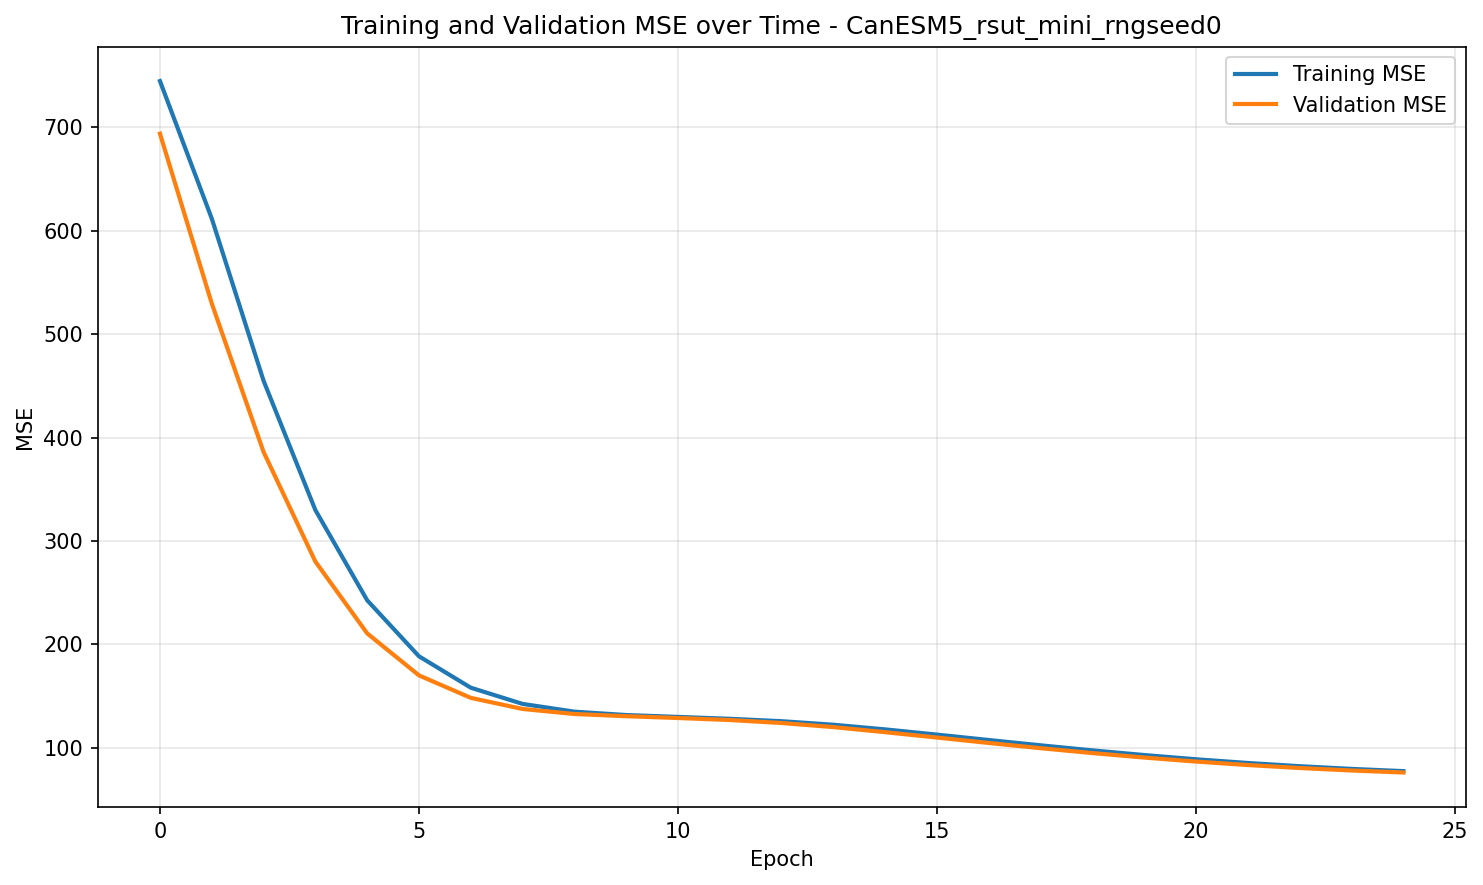

------CanESM5_rsut_mini DONE ------
------CanESM5_rlut_mini------
Loaded pre-split data:
  X_train: (33660, 64, 128, 1), y_train: (33660, 8192)
  X_val:   (7920, 64, 128, 1), y_val:   (7920, 8192)
  X_test:  (4128, 64, 128, 1), y_test:  (4128, 8192)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 128, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 128, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       524,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8192)           │       139,264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,680 (2.57 MB)

 Trainable params: 673,680 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
1052/1052 - 58s - 55ms/step - loss: 744.5453 - mae: 21.1070 - mse: 744.5453 - val_loss: 693.7104 - val_mae: 19.8229 - val_mse: 693.7104
Epoch 2/25
1052/1052 - 75s - 71ms/step - loss: 611.6356 - mae: 17.9621 - mse: 611.6356 - val_loss: 529.5843 - val_mae: 16.1592 - val_mse: 529.5843
Epoch 3/25
1052/1052 - 71s - 68ms/step - loss: 454.8439 - mae: 14.5790 - mse: 454.8439 - val_loss: 386.0425 - val_mae: 13.1273 - val_mse: 386.0425
Epoch 4/25
1052/1052 - 73s - 70ms/step - loss: 329.8348 - mae: 11.9372 - mse: 329.8348 - val_loss: 280.0734 - val_mae: 10.8672 - val_mse: 280.0734
Epoch 5/25
1052/1052 - 72s - 69ms/step - loss: 242.6378 - mae: 10.0572 - mse: 242.6378 - val_loss: 210.6573 - val_mae: 9.3548 - val_mse: 210.6573
Epoch 6/25
1052/1052 - 76s - 72ms/step - loss: 188.4981 - mae: 8.8728 - mse: 188.4981 - val_loss: 170.0594 - val_mae: 8.4644 - val_mse: 170.0594
Epoch 7/25
1052/1052 - 75s - 71ms/step - loss: 158.1575 - mae: 8.2047 - mse: 158.1575 - val_loss: 148.3449 - val_mae: 7.9

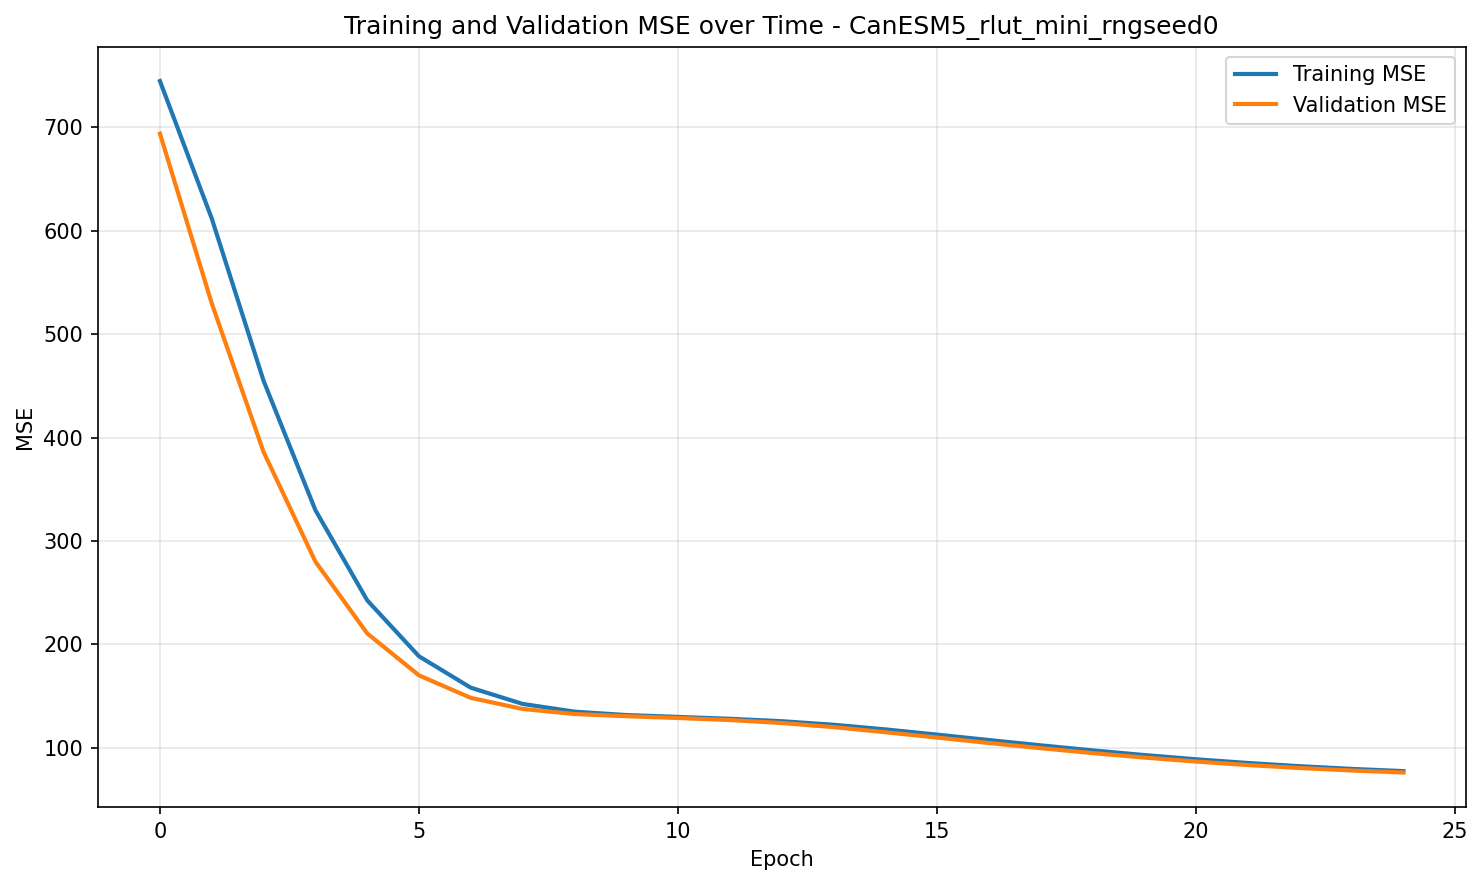

------CanESM5_rlut_mini DONE ------


In [8]:
# Mini Model Testing
plt.style.use("default")
mpl.rcParams["savefig.facecolor"] = "white"
mpl.rcParams["figure.dpi"] = 150
savefig_dpi = 300

EXP_NAME_LIST = (
    "CanESM5_rsut_mini",
    "CanESM5_rlut_mini",
)
OVERWRITE_MODEL = False

# ---------------------------------------------------------
# ---------------------------------------------------------

for EXP_NAME in EXP_NAME_LIST:
    print("------" + EXP_NAME + "------")
    settings = get_settings(EXP_NAME)

    for rng_seed in settings["rng_seed_list"]:
        settings["rng_seed"] = rng_seed
        tf.random.set_seed(settings["rng_seed"])
        random.seed(settings["rng_seed"])

        np.random.seed(settings["rng_seed"])


        model_name = get_model_name(settings)
        if os.path.exists(MODEL_DIRECTORY + model_name + "_model.keras") and OVERWRITE_MODEL is False:
            print("\n" + model_name + " exists. Skipping...")
            print("================================\n")
            continue

        (
            x_train,
            x_val,
            x_test,
            labels_train,
            labels_val,
            labels_test,
            lat,
            lon,
            map_shape,
            member_shape,
            time_shape,
            norm_dict,
            member_enrollment,
            settings,
        ) = load_presplit_data(settings, split_dir=DATA_DIRECTORY, verbose=1)

        tf.keras.backend.clear_session()
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_loss", patience=10, verbose=1, mode="auto", restore_best_weights=True
        )

        model = compile_model(x_train, labels_train, settings)
        model.summary()

        history = model.fit(
            x_train,
            labels_train,
            epochs=settings["n_epochs"],
            batch_size=settings["batch_size"],
            shuffle=True,
            validation_data=[x_val, labels_val],
            callbacks=[early_stopping],
            verbose=2,
        )

        predictions = {
            "labels_train": labels_train,
            "pred_train": model.predict(x_train),
            "labels_val": labels_val,
            "pred_val": model.predict(x_val),
            "labels_test": labels_test,
            "pred_test": model.predict(x_test),
        }

        _ = gc.collect()

        save_tf_model(model, model_name, MODEL_DIRECTORY, settings)
        save_predictions(predictions, PREDICTIONS_DIRECTORY + model_name + "_predictions.pickle")


        plot_metrics_panels(history, predictions)
        plt.savefig(
            DIAGNOSTICS_DIRECTORY + model_name + "_metrics_diagnostic.png",
            dpi=savefig_dpi,
            bbox_inches="tight",
        )
        plt.close()

        # Plot MSE loss over time (skipping first epoch)
        plt.figure(figsize=(10, 6))
        epochs_range = range(len(history.history['loss']))
        plt.plot(epochs_range, history.history['mse'][:], label='Training MSE', linewidth=2)
        plt.plot(epochs_range, history.history['val_mse'][:], label='Validation MSE', linewidth=2)
        plt.xlabel('Epoch')
        plt.ylabel('MSE')
        plt.title(f'Training and Validation MSE over Time - {model_name}')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        _ = gc.collect()

    print("------" + EXP_NAME + " DONE ------")